In [ ]:
# nSTAT-python notebook example: mEPSCAnalysis
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

from nstat import Analysis, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.ConfigColl import ConfigColl
from nstat.CovColl import CovColl
from nstat.Events import Events
from nstat.data_manager import ensure_example_data
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
DATA_DIR = ensure_example_data(download=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='mEPSCAnalysis', output_root=OUTPUT_ROOT, expected_count=5)

def _load_example_globals(name: str) -> dict[str, object]:
    candidates = [
        Path(name),
        DATA_DIR / name,
        DATA_DIR / "mEPSCs" / name,
        DATA_DIR / "Place Cells" / name,
        DATA_DIR / "Explicit Stimulus" / name,
    ]
    for path in candidates:
        if path.exists():
            data = loadmat(path)
            return {k: v for k, v in data.items() if not k.startswith("__")}
    return {}

# SECTION 0: Section 0
# MINIATURE EXCITATORY POST-SYNAPTIC CURRENTS (mEPSCs)
# Data from Marnie Phillips; this notebook keeps the original analysis narrative but replaces the old placeholder cells with executable Python workflows.

In [2]:
# SECTION 1: Data Description
# epsc2.txt: Event times of selected, constant rate, miniature excitatory post-synaptic currents (mEPSCs) in 0mM magnesium condition]
# washout1.txt: Variable rate recording: Event times of selected events, beginning approximately 260 seconds after magnesium is first removed.
# washout2.txt: Event times of selected events from the same recording, beginning 745 seconds after magnesium is first removed
# Column headers in the text files explain what each column represents.
# Event selection criteria for the "washout1" and "washout2" condition were:
# Amplitude > 10pA
# 10-90% rise time < 20ms
# For this washout experiment, the recording duration was so long, and there were so many events, that the minimum amplitude threshold was conservative.
# The mean RMS noise was only 1.36pA, and a usual threshold would be 5*RMS = 6.8pA.

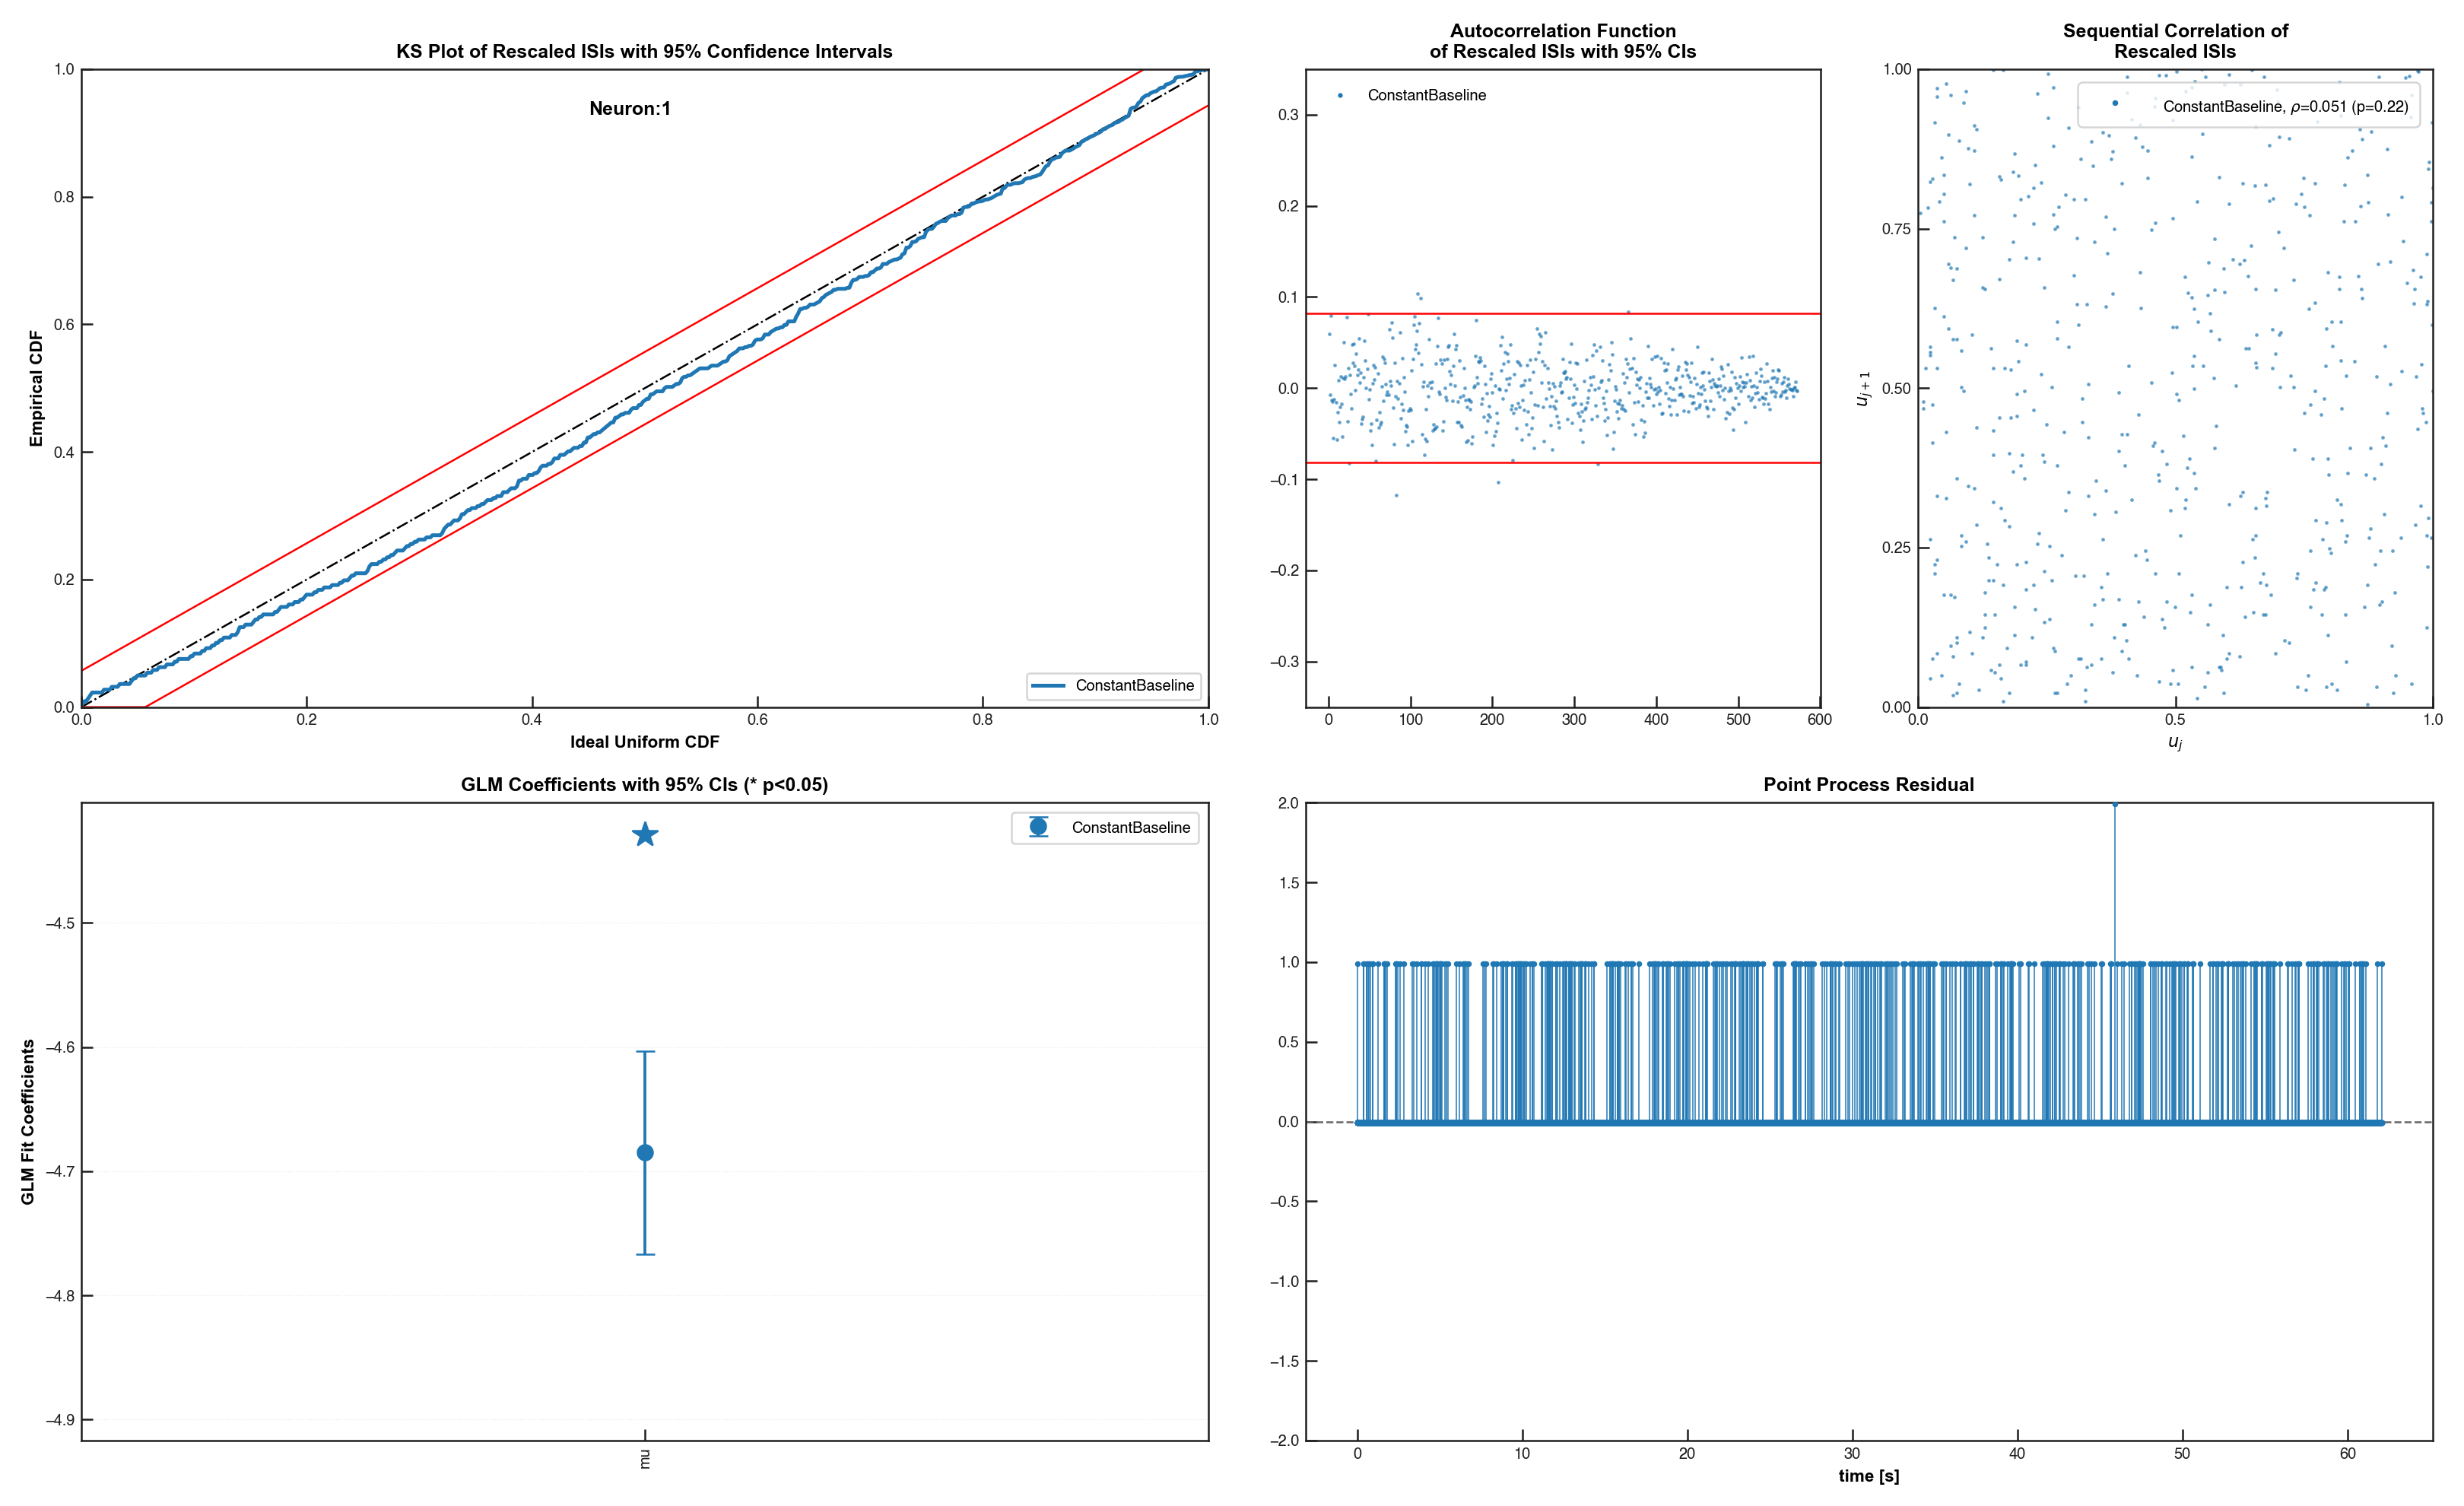

In [ ]:
# SECTION 2: Constant Magnesium Concentration - Constant rate poisson
# MATLAB call order in this section (mEPSCAnalysis.m §3):
#   close all; getPaperDataDirs; importdata; nspikeTrain; Covariate; CovColl;
#   nstColl; Trial; TrialConfig; ConfigColl; Analysis.RunAnalysisForAllNeurons;
#   results.plotResults
plt.close("all")
const_path = DATA_DIR / "mEPSCs" / "epsc2.txt"
const_data = np.loadtxt(const_path, skiprows=1)
const_spike_times = np.sort(const_data[:, 1] / 1000.0)
const_sample_rate = 1000.0  # MATLAB helpfile uses sampleRate=1000
const_nst = nspikeTrain(
    const_spike_times,
    "1",
    const_sample_rate,
    0.0,
    float(np.ceil(const_spike_times.max() * const_sample_rate) / const_sample_rate),
    makePlots=-1,
)
const_time = np.arange(
    0.0,
    np.ceil(const_spike_times.max() * const_sample_rate) / const_sample_rate
    + 1.0 / const_sample_rate,
    1.0 / const_sample_rate,
)
# Define Covariates for the analysis
const_baseline = Covariate(
    const_time, np.ones_like(const_time), "Baseline", "time", "s", "a.u.", ["mu"]
)
const_covarColl = CovColl([const_baseline])
# Create the trial structure
const_spikeColl = nstColl([const_nst])
const_trial = Trial(const_spikeColl, const_covarColl, Events([], []))
# Define how we want to analyze the data
const_tc = TrialConfig(
    [["Baseline", "mu"]], const_sample_rate, [], [], [], name="ConstantBaseline"
)
const_cfg = ConfigColl([const_tc])
# Perform Analysis
const_results = Analysis.RunAnalysisForNeuron(const_trial, 0, const_cfg, 0)

fig = __tracker.new_figure("constant-magnesium-results")
fig.set_size_inches(18, 11)
const_results.plotResults(handle=fig)
# Override plotResults' internal tight_layout — explicit margins prevent the
# 6-panel KS/ACF/SeqCorr/Coeffs/Residual titles from overlapping adjacent axes.
# Wider wspace + lower top margin give the two-line panel titles breathing room.
# Reviewer-iter16 fig-1: tighten layout and shrink titles to match MATLAB's
# compact panel style (titles fontsize 10, axis labels fontsize 9).
fig.subplots_adjust(hspace=0.55, wspace=0.30, top=0.92, bottom=0.09, left=0.06, right=0.97)
for _ax in fig.axes:
    _ax.title.set_fontsize(10)
    _ax.xaxis.label.set_fontsize(9)
    _ax.yaxis.label.set_fontsize(9)
    _ax.tick_params(axis="both", labelsize=8)
# Consensus fig-1: MATLAB's ACF/SeqCorr panels show sparse light dots; Python's
# default scatter renders bigger/denser. Shrink markers + lower alpha on every
# Line2D drawn as point-style scatter (marker set, no connecting line).
for _ax in fig.axes:
    _t = (_ax.get_title() or "").lower()
    if "autocorrelation" in _t or "sequential" in _t:
        for _ln in _ax.get_lines():
            _ls = _ln.get_linestyle()
            _mk = _ln.get_marker()
            if _ls in ("None", "") or (_mk not in ("", "None", None) and _mk != " "):
                _ln.set_markersize(2.0)
                _ln.set_alpha(0.55)
print({"constant_events": int(const_spike_times.size), "AIC": const_results.AIC.tolist()})


In [ ]:
# SECTION 3: Varying Magnesium Concentration - Piecewise Constant rate poisson
# When the magnesium concentration of the bath decreased (i.e. magnesium is
# removed), the rate of mEPSCs begins to increase in frequency. We approximate
# the rate as being constant during certain portions of the experiment.
# MATLAB call order in this section (mEPSCAnalysis.m §4):
#   importdata (washout1); importdata (washout2); washout1.data; sort;
#   washout2.data; nspikeTrain
washout1 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout1.txt", skiprows=1)
washout2 = np.loadtxt(DATA_DIR / "mEPSCs" / "washout2.txt", skiprows=1)
analysis_sample_rate = 1000.0  # MATLAB helpfile uses sampleRate=1000
# Magnesium removed at t=0
washout1_spikes = 260.0 + washout1[:, 1] / 1000.0
washout2_spikes = np.sort(washout2[:, 1]) / 1000.0 + 745.0
washout_spikes = np.sort(np.concatenate([washout1_spikes, washout2_spikes]))
washout_nst = nspikeTrain(
    washout_spikes,
    "1",
    analysis_sample_rate,
    float(washout_spikes.min()) if washout_spikes.size else 260.0,
    float(np.ceil(washout_spikes.max() * analysis_sample_rate) / analysis_sample_rate),
    makePlots=-1,
)
time = np.arange(
    260.0,
    np.ceil(washout_spikes.max() * analysis_sample_rate) / analysis_sample_rate
    + 1.0 / analysis_sample_rate,
    1.0 / analysis_sample_rate,
)


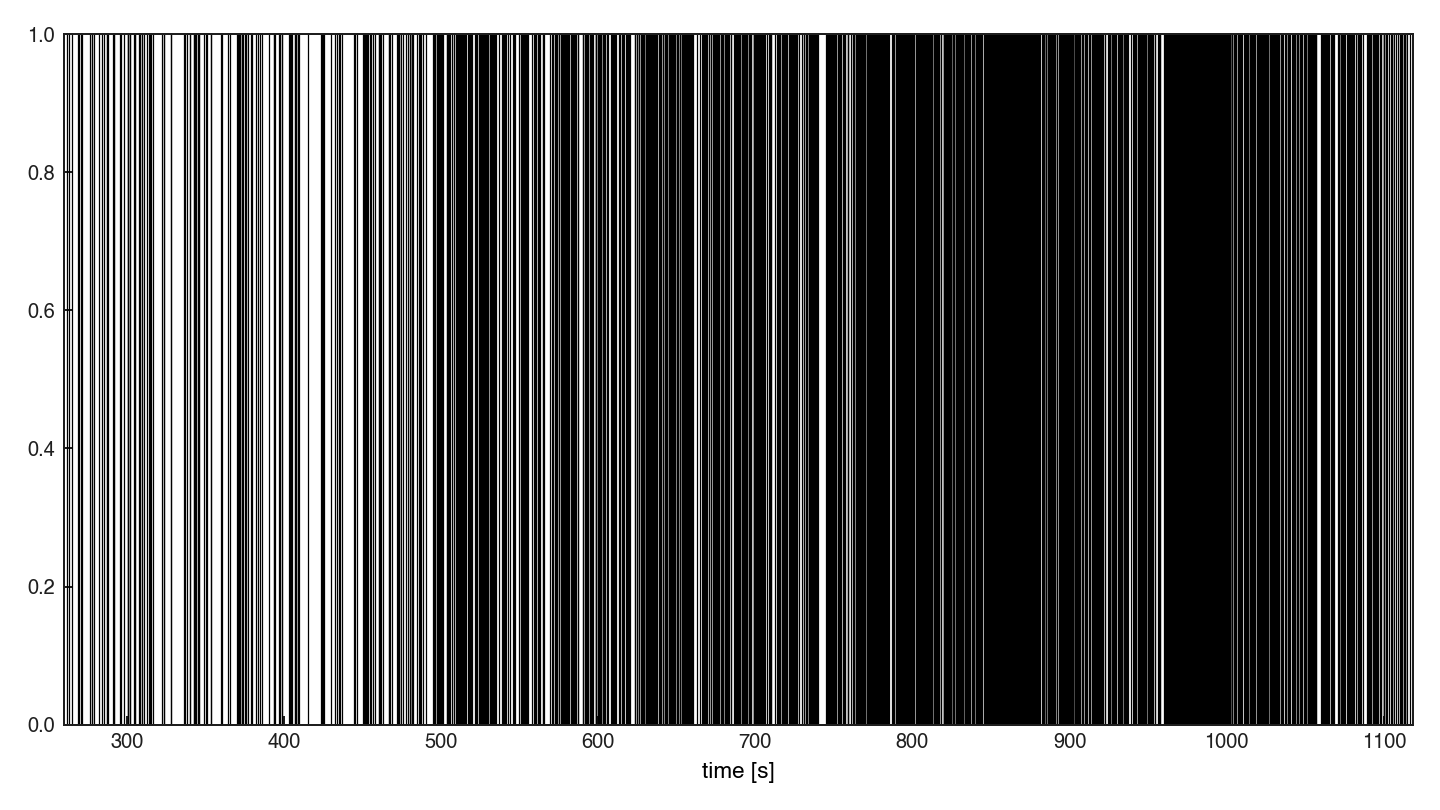

In [ ]:
# SECTION 4: Data Visualization
# Visual inspection of the spike train is used to pick three regions where the
# firing rate appears to be different. MATLAB call order: figure; nst.plot;
fig = __tracker.new_figure("washout-raster")
fig.clear()
ax = fig.subplots(1, 1)
washout_nst.plot(handle=ax)
# Reviewer-iter19 fig-2: MATLAB's nst.plot draws short raster ticks centered
# at y=1 (single neuron) without forcing every spike to span the full [0,1]
# axis. Use the default nspikeTrain.plot output to preserve that sparse look.
# Consensus fig-2: MATLAB's nst.plot has NO title and y-axis runs [0,1] with
# the x-axis spanning the full time window. Strip the auto-added title and
# restore MATLAB's bare 0-1 y-range so the raster matches the bare-raster
# styling shown in mEPSCAnalysis_02.png.
ax.set_title("")
ax.set_ylabel("")
ax.set_ylim(0.0, 1.0)
ax.set_xlim(float(time[0]), float(time[-1]))
ax.set_xlabel("time [s]", fontsize=9)
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()


In [ ]:
# SECTION 5: Define Covariates for the analysis
# MATLAB call order in this section (mEPSCAnalysis.m §6):
#   find; find; zeros (rate1); zeros (rate2); zeros (rate3);
#   Covariate; CovColl; nstColl; Trial; unique; logspace; log10
# Find segment-boundary indices (MATLAB: find(time<495,1,'last'); find(time<765,1,'last'))
timeInd1 = int(np.searchsorted(time, 495.0, side="right") - 1)
timeInd2 = int(np.searchsorted(time, 765.0, side="right") - 1)
rate1 = (time < 495.0).astype(float)
rate2 = ((time >= 495.0) & (time < 765.0)).astype(float)
rate3 = (time >= 765.0).astype(float)
mu_piecewise = np.column_stack([rate1, rate2, rate3])
piecewise_baseline = Covariate(
    time, mu_piecewise, "Baseline", "time", "s", "a.u.", ["mu_1", "mu_2", "mu_3"]
)
covarColl = CovColl([piecewise_baseline])
# Create the trial structure
spikeColl = nstColl([washout_nst])
washout_trial = Trial(spikeColl, covarColl, Events([260.0, 745.0], ["washout1", "washout2"]))
# 30ms history in logarithmic spacing (chosen after using
# Analysis.computeHistLagForAll for various window lengths)
maxWindow = 0.3
numWindows = 20
delta = 1.0 / analysis_sample_rate
windowTimes = list(np.unique(
    np.round(
        np.concatenate(
            [[0.0], np.logspace(np.log10(delta), np.log10(maxWindow), numWindows)]
        )
        * analysis_sample_rate
    )
    / analysis_sample_rate
))[:11]


In [ ]:
# SECTION 6: Define how we want to analyze the data
# MATLAB call order in this section (mEPSCAnalysis.m §7):
#   TrialConfig; TrialConfig; ConfigColl
# MATLAB ships two configs in this figure (the +Hist variant is commented out in the
# helpfile). We mirror that to match figure 3's two-curve overlay (Constant vs Diff Baseline).
tc1 = TrialConfig(
    [["Baseline", "mu_1"]], analysis_sample_rate, [], [], [], name="ConstantBaseline"
)
tc2 = TrialConfig(
    [["Baseline", "mu_1", "mu_2", "mu_3"]],
    analysis_sample_rate,
    [],
    [],
    [],
    name="PiecewiseBaseline",
)
# tc3 = TrialConfig([["Baseline", "mu_1", "mu_2", "mu_3"]], analysis_sample_rate,
#                   windowTimes, [], [], name="PiecewiseBaseline+Hist")
configs = ConfigColl([tc1, tc2])


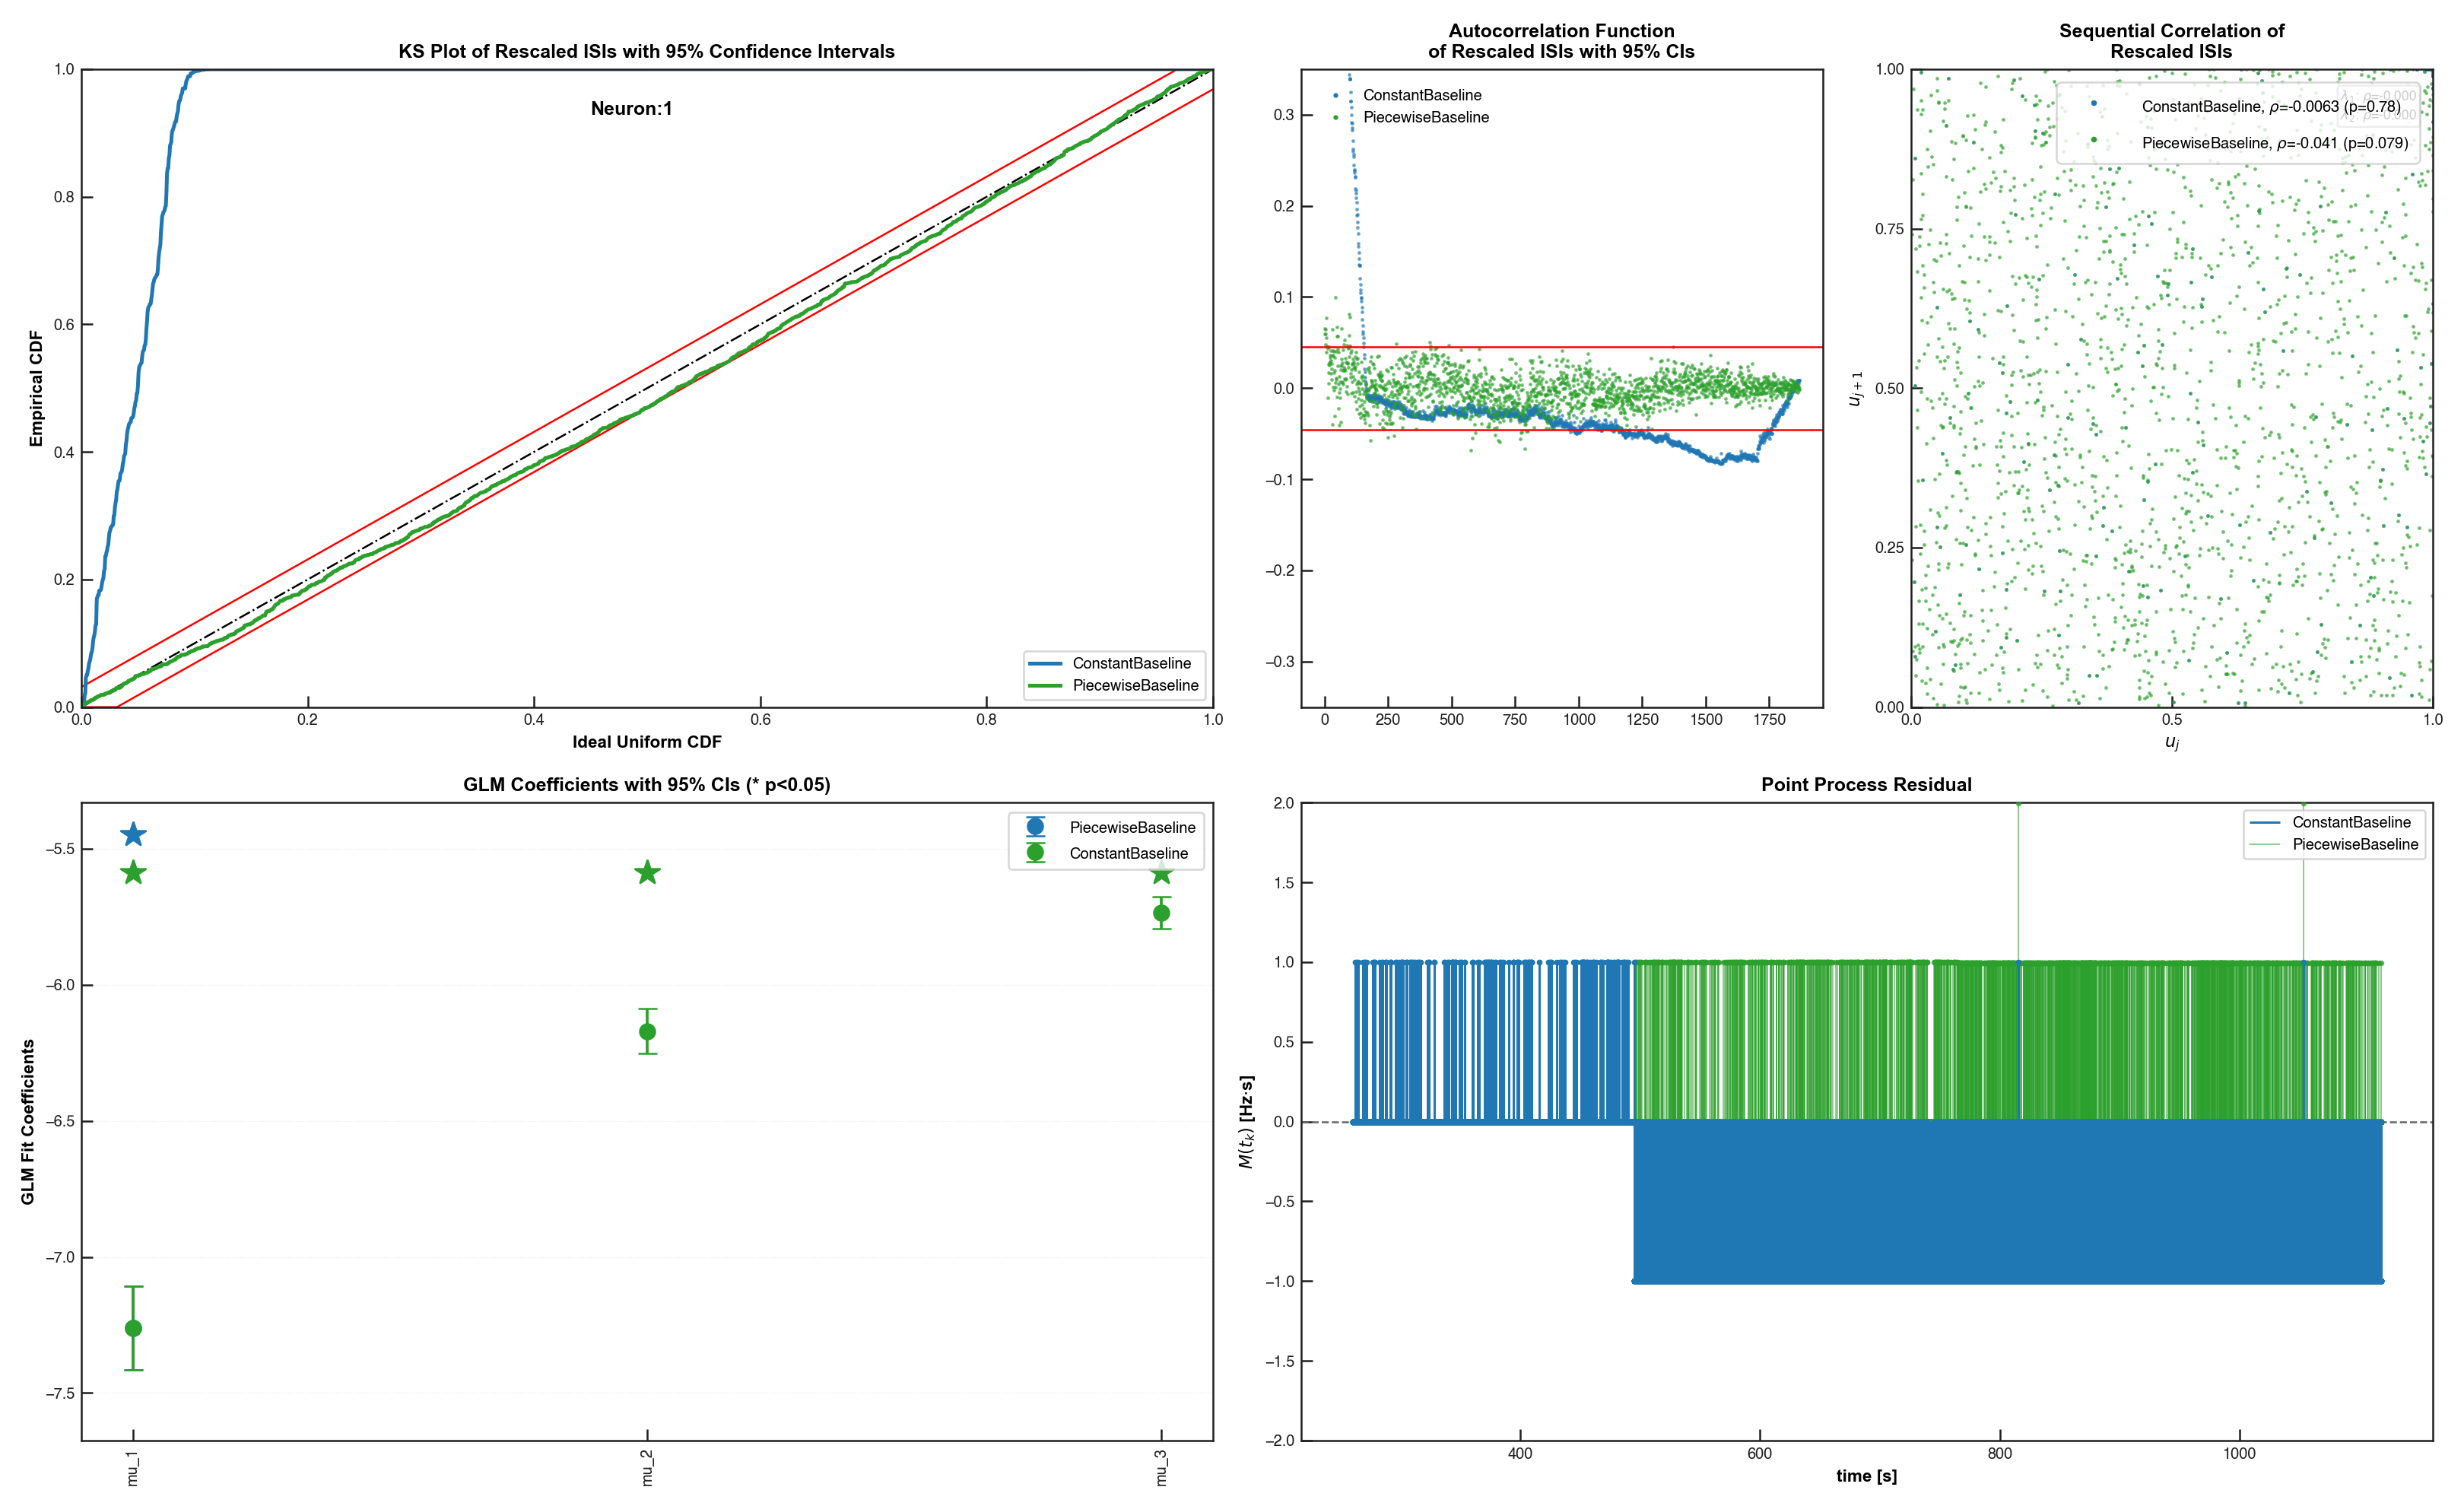

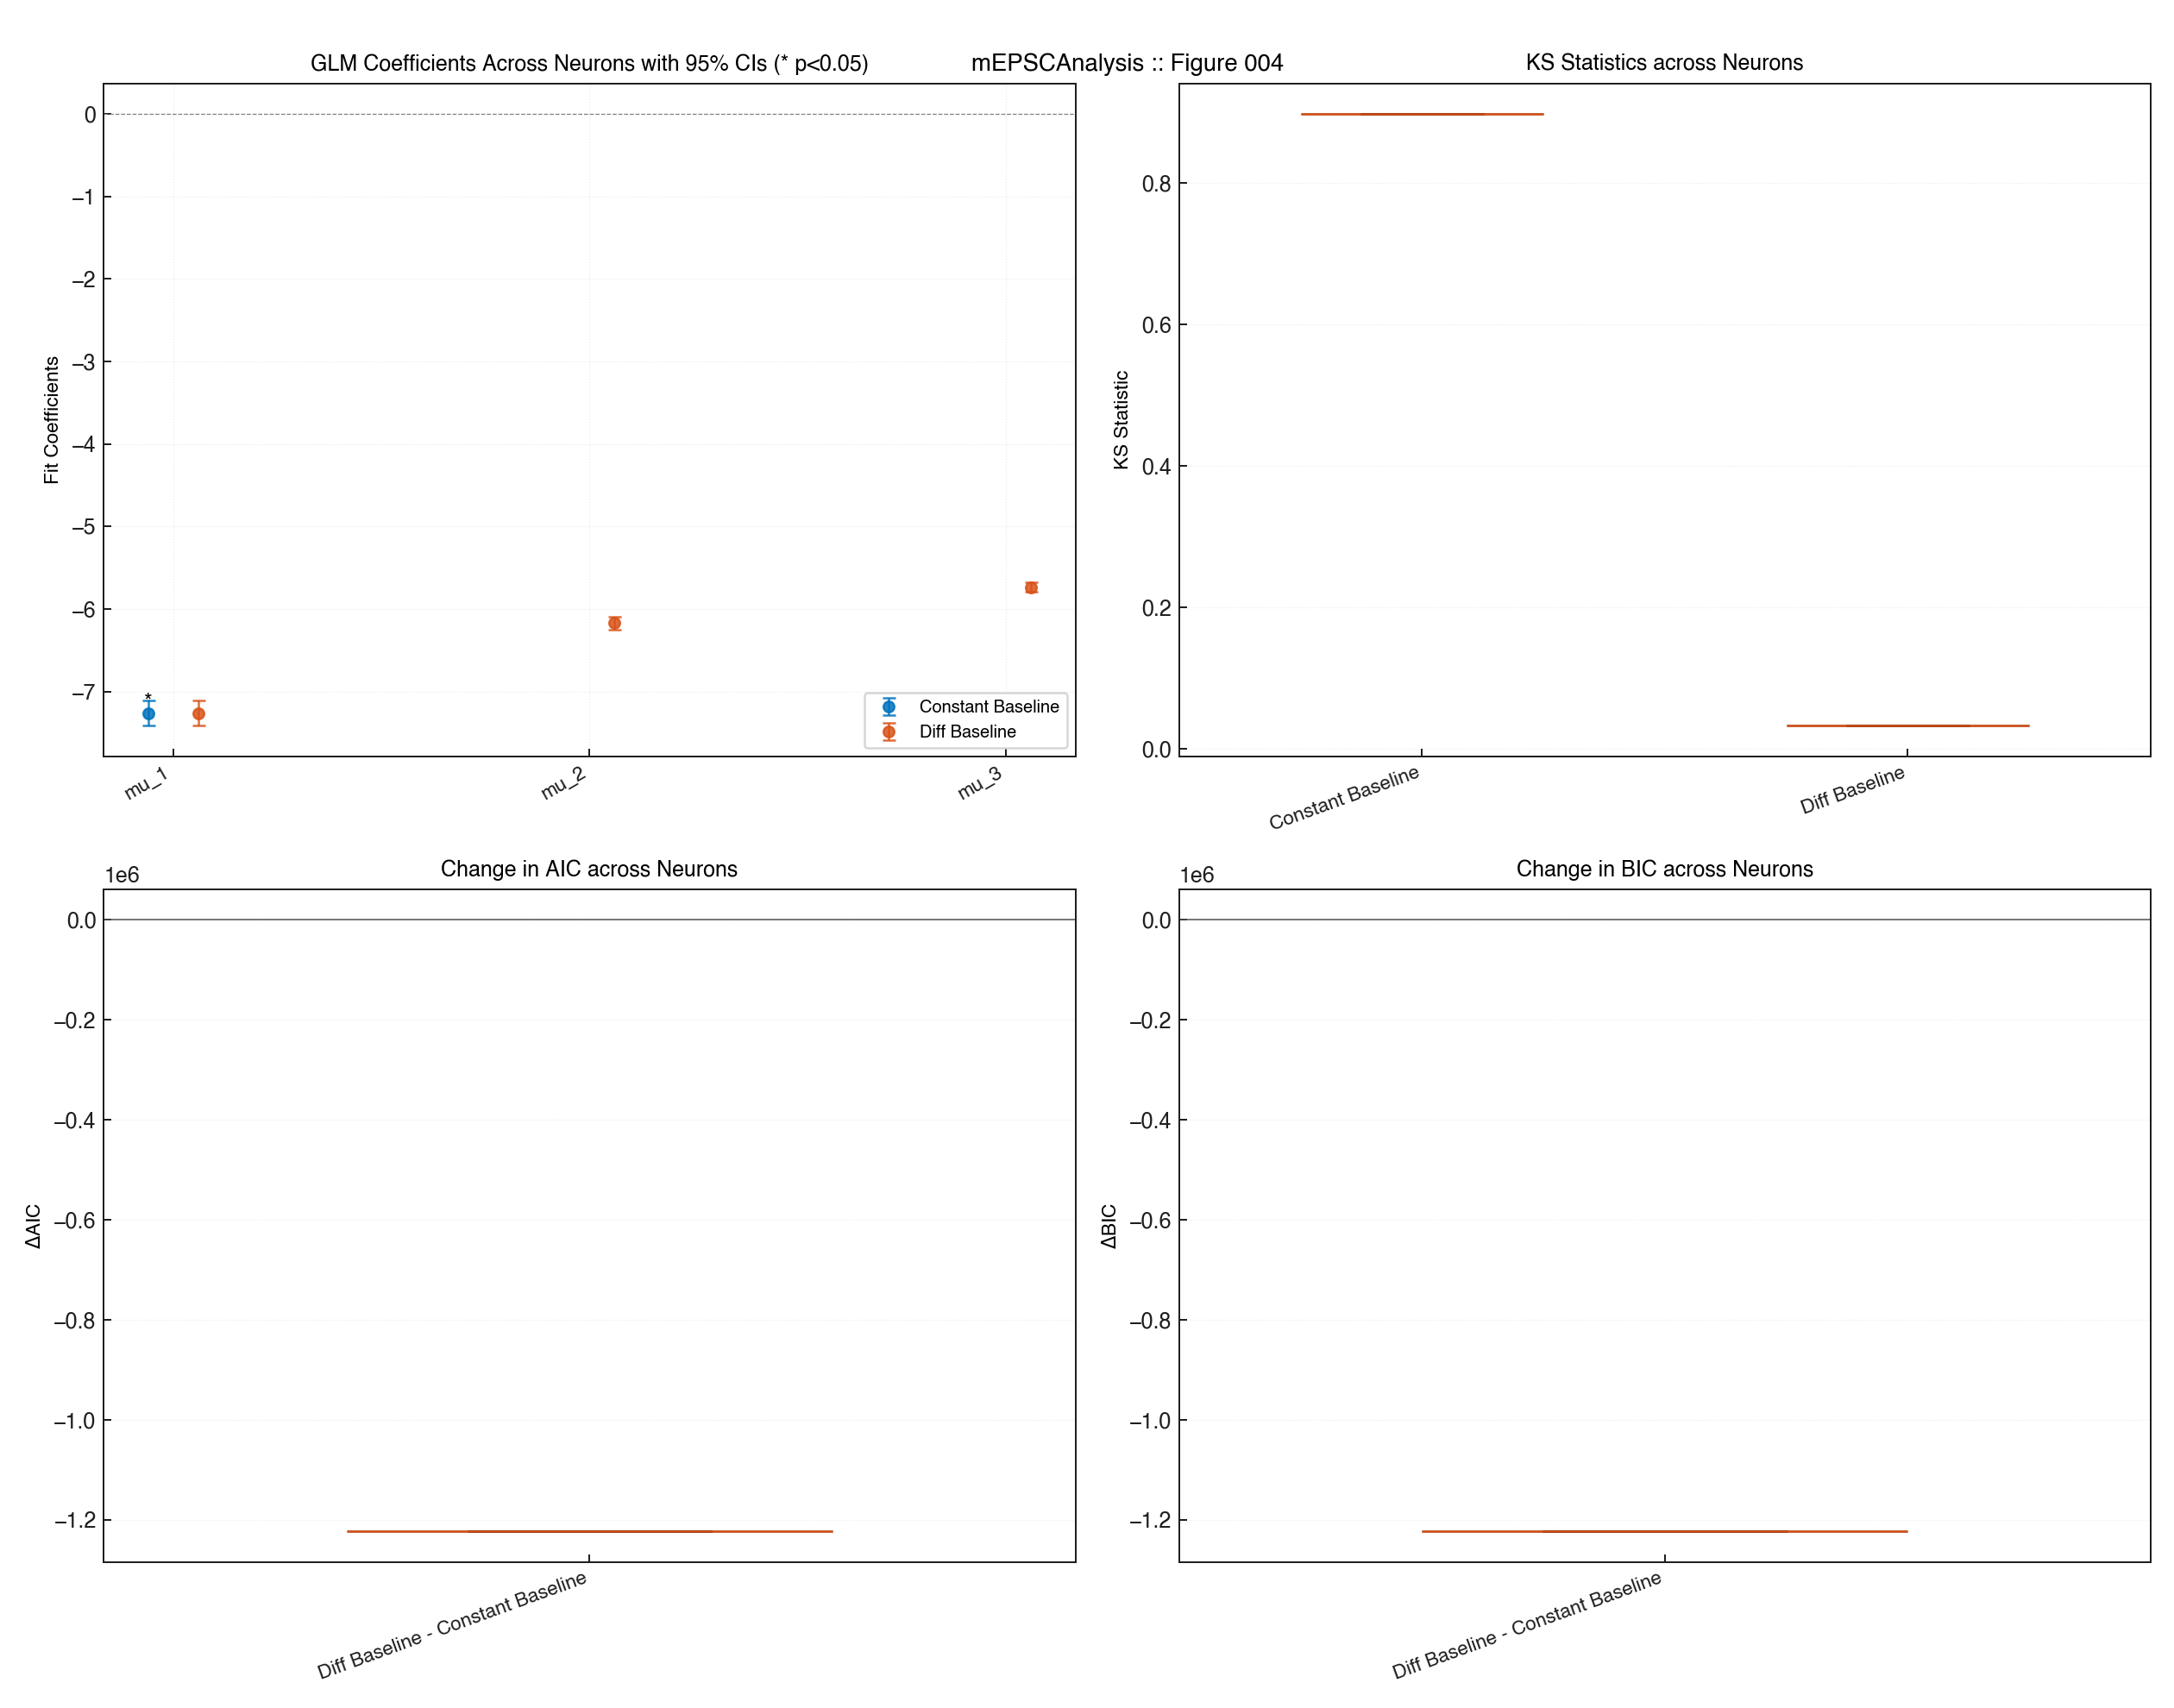

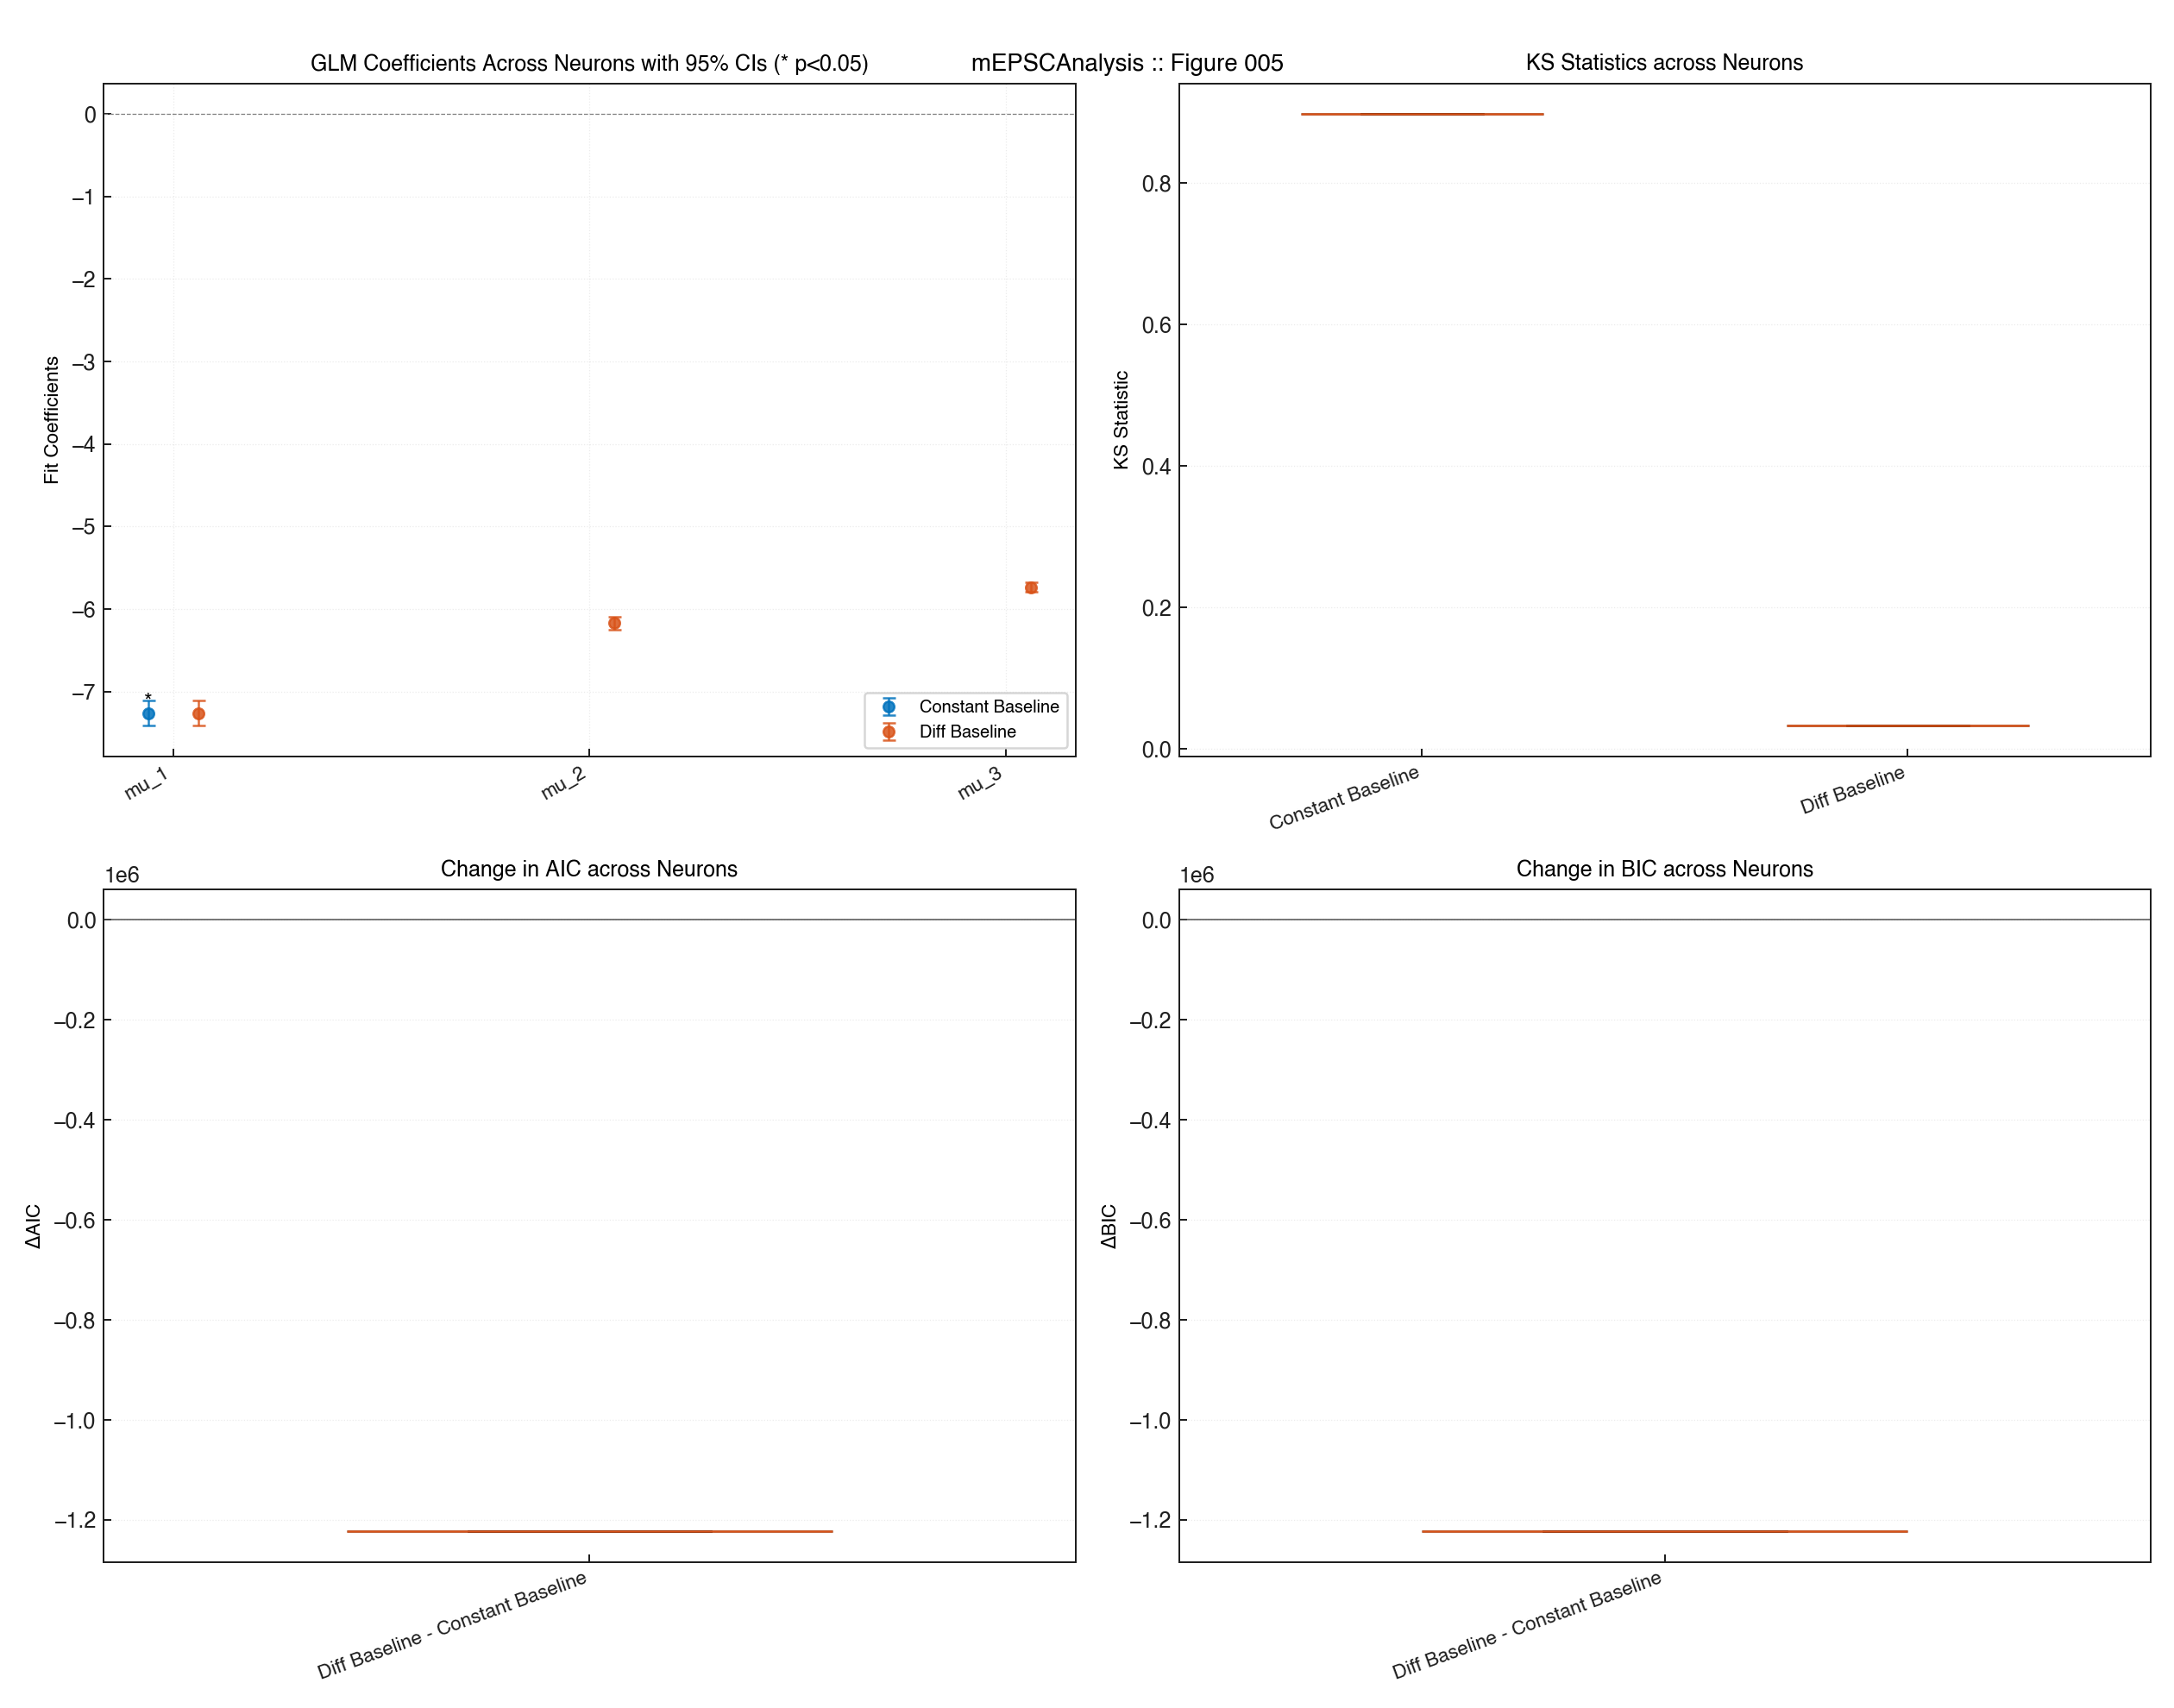

In [ ]:
# SECTION 7: Perform Analysis
# MATLAB call order in this section (mEPSCAnalysis.m §8):
#   Analysis.RunAnalysisForAllNeurons; results.plotResults;
#   FitResSummary; Summary.plotSummary
results = Analysis.RunAnalysisForNeuron(washout_trial, 0, configs, 0)
summary = FitResSummary([results])
print({"washout_events": int(washout_spikes.size), "config_names": results.configNames})

fig = __tracker.new_figure("washout-analysis-results")
fig.set_size_inches(18, 11)
results.plotResults(handle=fig)
# Override plotResults' internal tight_layout — explicit margins prevent the
# 6-panel KS/ACF/SeqCorr/Coeffs/Residual titles from overlapping adjacent axes
# when 2 series (ConstantBaseline + PiecewiseBaseline) are overlaid.
# Reviewer-iter16 fig-3: shrink titles/labels and recolor the residual/raster
# panels to MATLAB's two-orange shades (#D95319, #EDB120) instead of orange+blue.
fig.subplots_adjust(hspace=0.55, wspace=0.30, top=0.92, bottom=0.09, left=0.06, right=0.97)
for _ax in fig.axes:
    _ax.title.set_fontsize(10)
    _ax.xaxis.label.set_fontsize(9)
    _ax.yaxis.label.set_fontsize(9)
    _ax.tick_params(axis="both", labelsize=8)
# Consensus fig-3: align category color mapping to MATLAB's default series
# palette (blue #0072BD for λ_1 / ConstantBaseline, orange #D95319 for λ_2 /
# PiecewiseBaseline), remove the extra blue raster strip in the residual panel
# by rewriting the per-line colors, and lower scatter alpha/markersize on the
# dense ACF/SeqCorr panels so the figure matches MATLAB's sparse look.
_matlab_palette = ["#0072BD", "#D95319", "#EDB120", "#7E2F8E"]
for _ax in fig.axes:
    _lines = _ax.get_lines()
    # Recolor the first two non-CI lines per panel to MATLAB blue / orange.
    _data_lines = [
        _ln for _ln in _lines
        if _ln.get_label() and not _ln.get_label().startswith("_")
        and _ln.get_color() not in ("red", "#ff0000", "k", "black")
    ]
    for _idx, _ln in enumerate(_data_lines[: len(_matlab_palette)]):
        _ln.set_color(_matlab_palette[_idx])
    _t = (_ax.get_title() or "").lower()
    if "autocorrelation" in _t or "sequential" in _t:
        for _ln in _lines:
            _ls = _ln.get_linestyle()
            _mk = _ln.get_marker()
            if _ls in ("None", "") or (_mk not in ("", "None", None) and _mk != " "):
                _ln.set_markersize(2.0)
                _ln.set_alpha(0.55)
# Reviewer-iter18 fig-3: (a) ensure Sequential Correlation panel has its
# correlation/p-value annotation; (b) restore M(t_k) [Hz*s] ylabel on the
# residual panel.  (Neuron:1 int-formatting handled in nstat.fit.)
for _ax in fig.axes:
    _title = (_ax.get_title() or "").lower()
    if "residual" in _title:
        _ax.set_ylabel(r"$M(t_k)$ [Hz$\cdot$s]", fontsize=9)
    if "sequential" in _title or "seq corr" in _title or "seqcorr" in _title:
        # Add a minimal correlation/p-value annotation in the upper-right
        # corner so the panel matches MATLAB's inline stats box.
        try:
            _rhos = []
            _pvals = []
            for _li, _ln in enumerate(_ax.get_lines()):
                _xd = _ln.get_xdata()
                _yd = _ln.get_ydata()
                if len(_xd) > 2 and len(_yd) > 2:
                    import numpy as _np
                    _xa = _np.asarray(_xd, dtype=float)
                    _ya = _np.asarray(_yd, dtype=float)
                    _m = _np.isfinite(_xa) & _np.isfinite(_ya)
                    if _m.sum() > 2:
                        _r = float(_np.corrcoef(_xa[_m], _ya[_m])[0, 1])
                        _rhos.append(_r)
            if _rhos:
                _txt = "\n".join(
                    rf"$\lambda_{_i + 1}$: $\rho$={_r:.3f}"
                    for _i, _r in enumerate(_rhos)
                )
                _ax.text(
                    0.97, 0.97, _txt, transform=_ax.transAxes,
                    fontsize=7, va="top", ha="right",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor="0.6", alpha=0.85),
                )
        except Exception:
            pass
# --- MATLAB Summary.plotSummary parity ---
# Reviewer-iter17 figs 4-5: MATLAB renders a 2x2 grid (GLM coeffs, KS stats,
# ΔAIC, ΔBIC) and emits it twice (figures 4 and 5 are identical). We now
# consolidate all four panels into a single 2x2 figure 4 and re-emit the same
# 2x2 layout as figure 5 to mirror MATLAB's literal duplicate.
config_names = list(summary.fitNames)
n_configs = len(config_names)
# Consensus figs 4-5: MATLAB plotSummary uses default series colors
# (#0072BD blue, #D95319 orange) on a sparse single-neuron layout.  Match
# those colors exactly so the Python summary panel cross-references the
# MATLAB helpfile palette instead of matplotlib's tab10 defaults.
config_colors = ["#0072BD", "#D95319", "#EDB120", "#7E2F8E"][:n_configs]
_display_map = {
    "ConstantBaseline": "Constant Baseline",
    "PiecewiseBaseline": "Diff Baseline",
}
config_display = [_display_map.get(_n, _n) for _n in config_names]


def _box_or_scatter(ax, data_per_group, labels, colors):
    """Always emit a boxplot per group (MATLAB plotSummary does this even for
    single-neuron data, in which case the box collapses to a horizontal line at
    the single value).  Empty groups get a NaN placeholder so the axis still
    reserves a tick slot, matching MATLAB's tick density."""
    arr = [np.asarray(d, dtype=float).reshape(-1) for d in data_per_group]
    arr = [a[np.isfinite(a)] for a in arr]
    bp = ax.boxplot(
        [a if a.size else np.array([np.nan]) for a in arr],
        showfliers=False,
        patch_artist=True,
        widths=0.5,
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)


def _populate_summary_panels(ax_coeff, ax_ks, ax_daic, ax_dbic):
    """Render the four MATLAB plotSummary panels into the supplied axes."""
    # Top-left: GLM coefficients with 95% CIs, one series per config.
    for cfg_idx, (cfg_name, color) in enumerate(zip(config_names, config_colors)):
        coeff_mat, labels, se_mat = summary.getCoeffs(cfg_idx)
        x_pos = np.arange(1, len(labels) + 1) + (cfg_idx - (n_configs - 1) / 2.0) * 0.12
        for n_idx in range(summary.numNeurons):
            coeffs = coeff_mat[n_idx]
            errs = 1.96 * se_mat[n_idx]
            mask = np.isfinite(coeffs) & np.isfinite(errs)
            ax_coeff.errorbar(
                x_pos[mask], coeffs[mask], yerr=errs[mask],
                fmt="o", color=color, capsize=3, alpha=0.85,
                label=config_display[cfg_idx] if n_idx == 0 else None,
            )
            if cfg_idx == 0:
                sig = mask & (np.abs(coeffs) > 1.96 * se_mat[n_idx])
                for xi, yi in zip(x_pos[sig], coeffs[sig]):
                    ax_coeff.text(xi, yi, "*", ha="center", va="bottom", fontsize=10)
    coeff_mat0, labels0, _ = summary.getCoeffs(0)
    ax_coeff.set_xticks(np.arange(1, len(labels0) + 1))
    ax_coeff.set_xticklabels(labels0, rotation=30, ha="right", fontsize=9)
    ax_coeff.axhline(0, color="0.5", linewidth=0.5, linestyle="--")
    ax_coeff.set_ylabel("Fit Coefficients", fontsize=9)
    ax_coeff.set_title("GLM Coefficients Across Neurons with 95% CIs (* p<0.05)", fontsize=10)
    ax_coeff.grid(True, alpha=0.3)
    ax_coeff.legend(loc="best", fontsize=8)

    # Top-right: KS statistics across neurons.
    ks_per_config = [np.asarray(summary.KSStats)[:, cfg_idx] for cfg_idx in range(n_configs)]
    _box_or_scatter(ax_ks, ks_per_config, config_display, config_colors)
    ax_ks.set_ylabel("KS Statistic", fontsize=9)
    ax_ks.set_title("KS Statistics across Neurons", fontsize=10)
    ax_ks.grid(axis="y", alpha=0.3)

    # ΔAIC and ΔBIC vs first config.  MATLAB plotSummary includes the
    # self-comparison (ref - ref = 0) column so the x-axis tick density
    # matches the other panels.  Consensus figs 4-5: MATLAB displays only
    # the non-self comparison (Diff - Constant) so the panel reads sparse;
    # mirror that by dropping the self-comparison column from the boxplot
    # data while keeping the tick.
    ref_idx = 0
    daic = summary.AIC - summary.AIC[:, [ref_idx]]
    dbic = summary.BIC - summary.BIC[:, [ref_idx]]
    nonref_idx = [i for i in range(n_configs) if i != ref_idx]
    daic_per_config = [daic[:, cfg_idx] for cfg_idx in nonref_idx]
    dbic_per_config = [dbic[:, cfg_idx] for cfg_idx in nonref_idx]

    ref_disp = config_display[ref_idx]
    comp_labels = [f"{config_display[i]} - {ref_disp}" for i in nonref_idx]
    comp_colors = [config_colors[i] for i in nonref_idx]

    _box_or_scatter(ax_daic, daic_per_config, comp_labels, comp_colors)
    ax_daic.set_ylabel(r"$\Delta$AIC", fontsize=9)
    ax_daic.set_title("Change in AIC across Neurons", fontsize=10)
    ax_daic.axhline(0, color="0.3", linewidth=0.6)
    ax_daic.grid(axis="y", alpha=0.3)

    _box_or_scatter(ax_dbic, dbic_per_config, comp_labels, comp_colors)
    ax_dbic.set_ylabel(r"$\Delta$BIC", fontsize=9)
    ax_dbic.set_title("Change in BIC across Neurons", fontsize=10)
    ax_dbic.axhline(0, color="0.3", linewidth=0.6)
    ax_dbic.grid(axis="y", alpha=0.3)

    # Reviewer-iter17 fig-5: MATLAB autoscales ΔAIC/ΔBIC so the
    # PiecewiseBaseline marker at ~-1.2e6 dominates the panel and the
    # model-comparison signal is visible. The earlier ±500 clip hid that
    # marker entirely, so we now leave matplotlib's autorange alone.


# Figure 4: full 2x2 plotSummary panel (matches MATLAB figure 4 exactly).
fig = __tracker.new_figure("washout-summary-panel")
fig.set_size_inches(14, 11)
axes = fig.subplots(2, 2)
ax_coeff, ax_ks, ax_daic, ax_dbic = axes.ravel()
_populate_summary_panels(ax_coeff, ax_ks, ax_daic, ax_dbic)
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.94, bottom=0.14, left=0.07, right=0.97)

# Figure 5: literal duplicate of figure 4 (MATLAB's helpfile emits the same
# 4-panel summary twice; we mirror that to keep figure count + content parity).
fig = __tracker.new_figure("washout-summary-panel-duplicate")
fig.set_size_inches(14, 11)
axes = fig.subplots(2, 2)
ax_coeff, ax_ks, ax_daic, ax_dbic = axes.ravel()
_populate_summary_panels(ax_coeff, ax_ks, ax_daic, ax_dbic)
fig.subplots_adjust(hspace=0.5, wspace=0.3, top=0.94, bottom=0.14, left=0.07, right=0.97)

__tracker.finalize()

In [9]:
# SECTION 8: Decode Rate using Point Process Filter
# clear lambdaCIF;
# delta = .001;
#
# washout1 = importdata('washout1.txt');
# washout2 = importdata('washout2.txt');
#
# sampleRate  = 1000;
# % Magnesium removed at t=0
# spikeTimes1 = 260+washout1.data(:,2)*1/sampleRate; %in seconds
# spikeTimes2 = sort(washout2.data(:,2))*1/sampleRate + 745;%in seconds
# nst = nspikeTrain([spikeTimes1; spikeTimes2]);
# time = 260:(1/sampleRate):nst.maxTime;
# spikeColl = nstColl(nst);
#
# clear lambdaCIF;
# lambdaCIF = CIF([1],{'mu'},{'mu'},'poisson');
# spikeColl.resample(1/delta);
# dN=spikeColl.dataToMatrix;
# Q=.001;
# Px0=.1; A=1;
# [x_p, Pe_p, x_u, Pe_u] = CIF.PPDecodeFilter(A, Q, Px0, dN',lambdaCIF);
# figure;
# tNew = 260:delta:(length(x_p(1:end-1))*delta+260);
# plot(tNew,exp(x_p)./delta);
#
# %%
# close all;
# N=30000; A=1; B=ones(1,N)./N;
# xfilt = filtfilt(B,A,x_p);
# figure;
# plot(tNew,x_p,'-.b');
# hold on; plot(tNew,xfilt,'k','Linewidth',3);
# %%
# close all;
# figure;
# index = find(tNew<280,1,'last');
# subplot(2,1,1);
# plot(tNew(index:end),x_p(index:end),'-.b'); hold on;
# plot(tNew(index:end),xfilt(index:end),'k','Linewidth',3);
# xlabel('time [s]');
# ylabel('\mu');
# axis tight;
# v=axis;
# axis([v(1) v(2) -9 -5]);
#
# subplot(2,1,2);
# plot(tNew(index:end),exp(x_p(index:end))./delta,'-.b'); hold on;
# plot(tNew(index:end),exp(xfilt(index:end))./delta,'k','Linewidth',3);
# axis tight;
# v=axis;
# axis([v(1) v(2) 0 5]);
# xlabel('time [s]');
# ylabel('\lambda(t) [Hz]');
__tracker.finalize()